# 02. Exploratory Description of the Place-Year Table

Notebook 01 produced a cleaned place-year table of 2,182 rows. This notebook describes that table. Exploratory description precedes confirmatory testing so that the shape of the dependent variable and the three locked predictors is on record before any slope is fit (Tukey, 1977).

The analysis file is `data/processed/place_year_clean.csv`. The variables under description are the property-crime rate per 100,000 and the three locked predictors: poverty rate, Blau ethnic heterogeneity, and the share of residents who moved in the last year.

We highlight three **Northern Utah** cities — Ogden, Layton, and Logan — throughout the visualizations. These are expanding cities: between 2022 and 2024, Ogden grew 0.8%, Layton grew 1.9% and Logan grew 3.1%, all well above the national median city growth of 0.4%. Expanding cities attract new plant, property, and equipment investment, which makes the property-crime question operationally relevant for owners evaluating sites. The project plan names Northern Utah as the owner briefing case.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
if (HERE / "data" / "processed" / "place_year_clean.csv").exists():
    ROOT = HERE
elif (HERE.parent / "data" / "processed" / "place_year_clean.csv").exists():
    ROOT = HERE.parent
else:
    raise FileNotFoundError("Run this notebook from the Capstone root or from scripts/.")

CLEAN = ROOT / "data" / "processed" / "place_year_clean.csv"
FIGDIR = ROOT / "scripts" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)

H0_COLS = [
    "property_crime_rate",
    "poverty_rate",
    "blau_heterogeneity",
    "pct_moved_year",
]
LABELS = {
    "property_crime_rate": "Property-crime rate per 100,000",
    "poverty_rate": "Poverty rate (%)",
    "blau_heterogeneity": "Blau heterogeneity",
    "pct_moved_year": "Moved in last year (%)",
    "foreign_born_share": "Foreign-born share (%)",
}

sns.set_theme(style="whitegrid", context="notebook")
print("ROOT", ROOT)
print("clean file", CLEAN)
print("figures", FIGDIR)


ROOT C:\Users\Owner\OneDrive\Capstone
clean file C:\Users\Owner\OneDrive\Capstone\data\processed\place_year_clean.csv
figures C:\Users\Owner\OneDrive\Capstone\scripts\figures


## File Gate

The gate confirms the cleaned table is on disk.

In [2]:
assert CLEAN.exists(), CLEAN
df = pd.read_csv(CLEAN)
missing_cols = [c for c in H0_COLS + ["geoid", "year", "place", "state_abbr", "arson"] if c not in df.columns]
print("rows", len(df), "columns", df.shape[1])
print("missing required columns", missing_cols)
assert not missing_cols, missing_cols
assert len(df) >= 200, len(df)
print("n >= 200 gate passed")


rows 2182 columns 30
missing required columns []
n >= 200 gate passed


## Sample Confirmation

The unit remains the place-year. Confirmation reprints the year split and the number of unique places so the exploratory figures can be read against the same universe that notebook 01 wrote.

In [3]:
print(df.groupby("year").size())
print("unique places", df["geoid"].nunique())

NU_PLACES = ["Ogden city", "Layton city", "Logan city"]
NU_LABELS = {"Ogden city": "Ogden", "Layton city": "Layton", "Logan city": "Logan"}
NU_MARKERS = {"Ogden city": "D", "Layton city": "s", "Logan city": "^"}
NU_COLORS = {"Ogden city": "#d62728", "Layton city": "#2ca02c", "Logan city": "#9467bd"}
nu = df.loc[df["place"].isin(NU_PLACES)].copy()
nu["city"] = nu["place"].map(NU_LABELS)
ogden = nu[nu["place"] == "Ogden city"]

print("\nNorthern Utah briefing cities")
print(nu[["year", "city", "acs_population", "property_crime_count",
          "property_crime_rate", "poverty_rate", "blau_heterogeneity",
          "pct_moved_year", "foreign_born_share"]]
      .sort_values(["city", "year"]).to_string(index=False))

print("\nPopulation growth (2022 \u2192 2024)")
nat_med_22 = df[df["year"] == 2022]["acs_population"].median()
nat_med_24 = df[df["year"] == 2024]["acs_population"].median()
print(f"  National median city: {nat_med_22:,.0f} \u2192 {nat_med_24:,.0f} "
      f"(+{(nat_med_24 - nat_med_22) / nat_med_22 * 100:.1f}%)")
for place in NU_PLACES:
    c = nu[nu["place"] == place].sort_values("year")
    p22 = c[c["year"] == 2022]["acs_population"].iloc[0]
    p24 = c[c["year"] == 2024]["acs_population"].iloc[0]
    print(f"  {NU_LABELS[place]}: {p22:,.0f} \u2192 {p24:,.0f} "
          f"(+{(p24 - p22) / p22 * 100:.1f}%)")


year
2022    706
2023    731
2024    745
dtype: int64
unique places 771

Northern Utah briefing cities
 year   city  acs_population  property_crime_count  property_crime_rate  poverty_rate  blau_heterogeneity  pct_moved_year  foreign_born_share
 2022 Layton         81726.0                1410.0          1725.277146           7.5            0.368313            12.6            6.175513
 2023 Layton         82512.0                1246.0          1510.083382           7.0            0.380249            12.5            6.399069
 2024 Layton         83286.0                1131.0          1357.971328           8.1            0.389106            11.6            6.864299
 2022  Logan         53246.0                 716.0          1344.701949          24.1            0.403994            29.9            8.586560
 2023  Logan         53923.0                 786.0          1457.634034          23.0            0.409989            30.2            9.411568
 2024  Logan         54907.0                 

The year split matches notebook 01: 706, 731, 745. All three Northern Utah briefing cities are in the study and are growing faster than the national median city (0.4% over the panel): Logan added 3.1%, Layton 1.9%, and Ogden 0.8%. Growing cities draw new PPE investment, making the property-crime question directly relevant.

The actual crime counts tell the short story: Ogden reported 2,204 property crimes in 2022 and 1,680 in 2024 (−524). Layton went from 1,410 to 1,131 (−279). Logan went from 716 to 634 (−82). Crime is falling in all three cities. Whether the predictors support that trend continuing is what the rest of the analysis answers.

## Univariate Description

Tukey (1977) treats the histogram, the five-number summary, and the interquartile rule as the first record of a batch. We apply that sequence to the property-crime rate and to each locked predictor. Interquartile flags mark tails only.

Poverty and mobility are ACS percentages on a 0–100 scale. Blau heterogeneity is bounded between 0 and \(1 - 1/k\) for the eight-group partition locked in notebook 01 (Blau, 1977; Messner, 1986). The rate is a count per 100,000 residents with no fixed upper bound.

In [4]:
def iqr_bounds(s: pd.Series) -> pd.Series:
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    return pd.Series(
        {
            "n": int(s.notna().sum()),
            "null_values": int(s.isna().sum()),
            "mean": s.mean(),
            "std": s.std(),
            "min": s.min(),
            "q1": q1,
            "median": s.median(),
            "q3": q3,
            "max": s.max(),
            "iqr": iqr,
            "iqr_low": q1 - 1.5 * iqr,
            "iqr_high": q3 + 1.5 * iqr,
            "iqr_flags": int(((s < q1 - 1.5 * iqr) | (s > q3 + 1.5 * iqr)).sum()),
        }
    )


uni = pd.DataFrame({c: iqr_bounds(df[c]) for c in H0_COLS}).T
print(uni.round(3))
print()
print(df[H0_COLS].describe())


                          n  null_values      mean       std    min        q1  \
property_crime_rate  2182.0          0.0  2320.090  1161.883  0.000  1460.856   
poverty_rate         2182.0          0.0    13.093     6.325  2.600     8.000   
blau_heterogeneity   2182.0          0.0     0.548     0.135  0.058     0.462   
pct_moved_year       2182.0          0.0    14.570     5.254  3.400    10.900   

                       median        q3       max       iqr  iqr_low  \
property_crime_rate  2094.274  2917.920  9826.695  1457.064 -724.739   
poverty_rate           12.150    17.100    37.300     9.100   -5.650   
blau_heterogeneity      0.580     0.652     0.783     0.190    0.176   
pct_moved_year         13.900    17.000    38.100     6.100    1.750   

                     iqr_high  iqr_flags  
property_crime_rate  5103.515       58.0  
poverty_rate           30.750       17.0  
blau_heterogeneity      0.937       17.0  
pct_moved_year         26.150       74.0  

       property_c

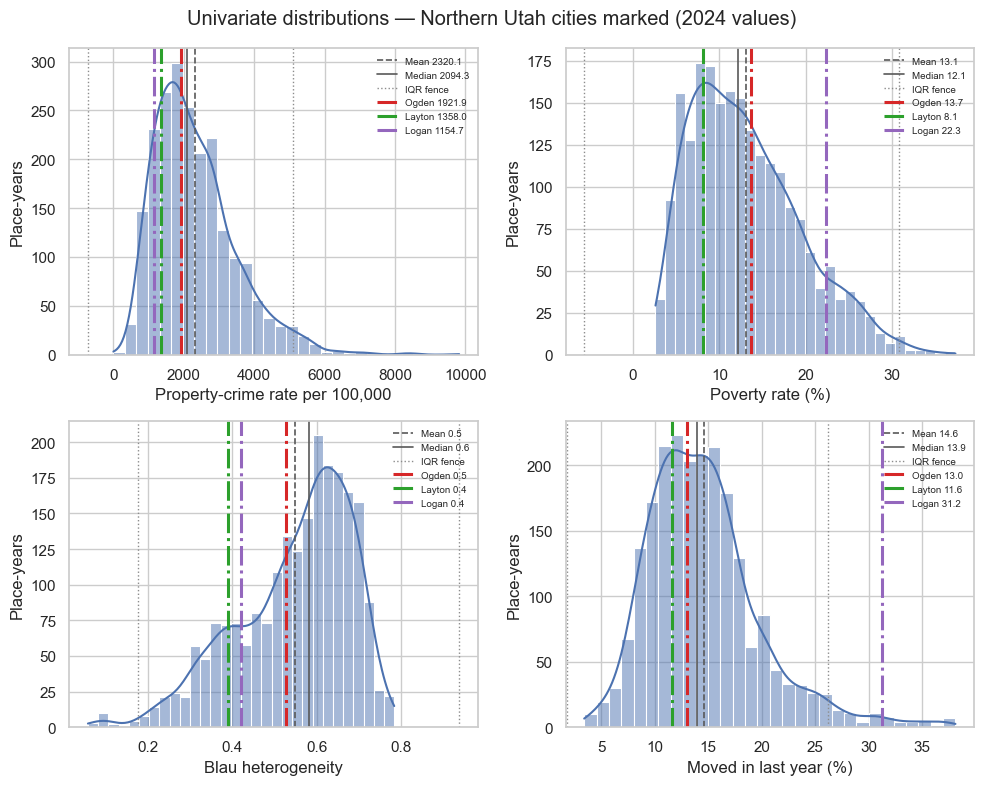

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\02_univariate_histograms.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), H0_COLS):
    sns.histplot(df[col], bins=30, kde=True, ax=ax, color="#4C72B0", edgecolor="white")
    ax.axvline(df[col].mean(), color="0.35", linestyle="--", linewidth=1.2, label=f"Mean {df[col].mean():.1f}")
    ax.axvline(df[col].median(), color="0.35", linestyle="-", linewidth=1.2, label=f"Median {df[col].median():.1f}")
    q1, q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    iqr = q3 - q1
    ax.axvline(q1 - 1.5 * iqr, color="0.55", linestyle=":", linewidth=1, label="IQR fence")
    ax.axvline(q3 + 1.5 * iqr, color="0.55", linestyle=":", linewidth=1)
    for place in NU_PLACES:
        vals = nu.loc[(nu["place"] == place) & (nu["year"] == 2024), col]
        if not vals.empty:
            v = vals.iloc[0]
            ax.axvline(v, color=NU_COLORS[place], linestyle="-.", linewidth=2.2,
                       label=f"{NU_LABELS[place]} {v:.1f}")
    ax.set_xlabel(LABELS[col])
    ax.set_ylabel("Place-years")
    ax.legend(frameon=False, fontsize=7, loc="upper right")
fig.suptitle("Univariate distributions \u2014 Northern Utah cities marked (2024 values)")
fig.tight_layout()
hist_path = FIGDIR / "02_univariate_histograms.png"
fig.savefig(hist_path, dpi=150)
plt.show()
print("wrote", hist_path)


The property-crime rate is right-skewed. The median is about 2,100 per 100,000; the mean is higher, and a long upper tail reaches nearly 10,000. Fifty-eight place-years fall above the interquartile fence.

Poverty and percent moved are unimodal on the ACS 0–100 scale, with medians near 12% and 14%. Blau heterogeneity is concentrated between about 0.45 and 0.65. The eight-group ceiling is 0.875; the observed maximum (0.78) stays well below that bound.

The Northern Utah cities are marked at their 2024 values. Ogden’s poverty (13.7%) sits just above the national median, while Logan’s (22.3%) is deep in the upper tail. Layton’s values cluster near the lower end of every distribution. On the mobility panel, Logan’s 31.2% sits far beyond the upper IQR fence.

## Bivariate Description

Each scatter plots one locked predictor against the property-crime rate. The cloud is the national place-year sample. The three Northern Utah briefing cities are overplotted so the owner can read their positions against that cloud.

The pairwise Pearson matrix measures linear association between two interval variables (Pearson, 1896).

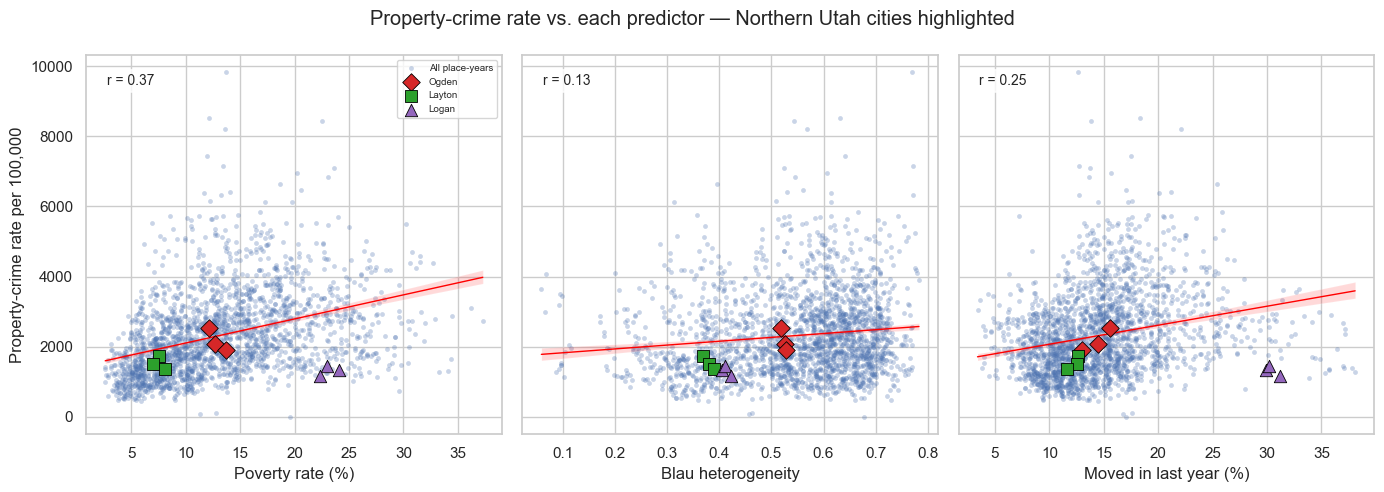

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\02_bivariate_scatters.png


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
predictors = ["poverty_rate", "blau_heterogeneity", "pct_moved_year"]
for ax, col in zip(axes, predictors):
    ax.scatter(
        df[col],
        df["property_crime_rate"],
        s=12,
        alpha=0.30,
        c="#4C72B0",
        linewidths=0,
        label="All place-years",
    )
    sns.regplot(
        x=df[col],
        y=df["property_crime_rate"],
        ax=ax,
        scatter=False,
        line_kws={"color": "red", "linewidth": 1},
    )
    r = df[col].corr(df["property_crime_rate"])
    ax.text(
        0.05, 0.95, f"r = {r:.2f}",
        transform=ax.transAxes, fontsize=10, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8),
    )
    for place in NU_PLACES:
        subset = nu[nu["place"] == place]
        ax.scatter(
            subset[col],
            subset["property_crime_rate"],
            s=80,
            c=NU_COLORS[place],
            marker=NU_MARKERS[place],
            edgecolors="black",
            linewidths=0.6,
            zorder=3,
            label=NU_LABELS[place],
        )
    ax.set_xlabel(LABELS[col])
    ax.set_ylabel(LABELS["property_crime_rate"] if ax is axes[0] else "")
axes[0].legend(frameon=True, fontsize=7, loc="upper right")
fig.suptitle("Property-crime rate vs. each predictor — Northern Utah cities highlighted")
fig.tight_layout()
scatter_path = FIGDIR / "02_bivariate_scatters.png"
fig.savefig(scatter_path, dpi=150)
plt.show()
print("wrote", scatter_path)


Each panel is a scatter cloud with a fitted regression line and a Pearson coefficient. Higher poverty and higher mobility sit with a higher property-crime rate on average, with wide scatter at every level of the predictor. The Blau panel is flatter: places span most of the 0–0.88 range while the rate still varies by several thousand per 100,000. Heterogeneity’s association with the rate is weaker than poverty’s.

The three Northern Utah cities (colored markers) illustrate distinct positions in the national cloud. **Logan** (triangles) sits far to the right on both the poverty and mobility panels — its university-town profile (poverty ~22–24%, mobility ~30%) places it among the highest-risk predictor values, even though it recorded only 634–786 property crimes per year. **Ogden** (diamonds) falls near the center of each panel, with its three years drifting right on poverty; its 1,680–2,204 annual offenses make it the highest-count city of the three. **Layton** (squares) clusters in the low-poverty, low-mobility corner with 1,131–1,410 offenses. An owner comparing sites across these three expanding cities would see strikingly different risk profiles on the same predictors.

### Preliminary Look: Foreign-Born Share

Foreign-born population share is not one of the three locked predictors. It appears here because a common shortcut treats it as a crime-risk signal. Notebook 04 will test that assumption with a formal regression; the plots below set the visual baseline.

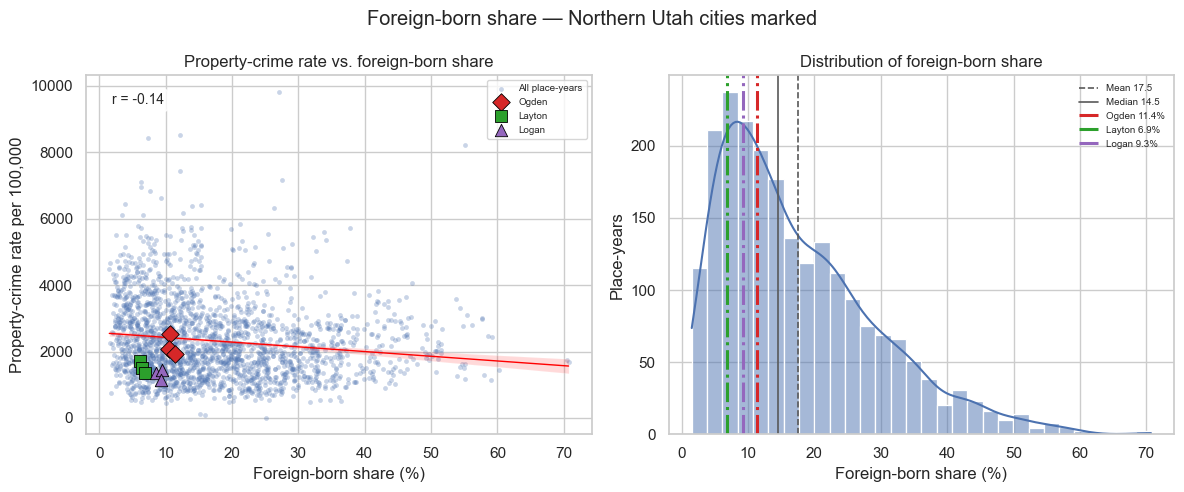

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\02_foreign_born_scatter.png


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: scatter of foreign_born_share vs property_crime_rate
ax = axes[0]
ax.scatter(df["foreign_born_share"], df["property_crime_rate"],
           s=12, alpha=0.30, c="#4C72B0", linewidths=0, label="All place-years")
sns.regplot(x=df["foreign_born_share"], y=df["property_crime_rate"],
            ax=ax, scatter=False, line_kws={"color": "red", "linewidth": 1})
r = df["foreign_born_share"].corr(df["property_crime_rate"])
ax.text(0.05, 0.95, f"r = {r:.2f}", transform=ax.transAxes, fontsize=10,
        verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))
for place in NU_PLACES:
    subset = nu[nu["place"] == place]
    ax.scatter(subset["foreign_born_share"], subset["property_crime_rate"],
               s=80, c=NU_COLORS[place], marker=NU_MARKERS[place],
               edgecolors="black", linewidths=0.6, zorder=3,
               label=NU_LABELS[place])
ax.set_xlabel(LABELS["foreign_born_share"])
ax.set_ylabel(LABELS["property_crime_rate"])
ax.legend(frameon=True, fontsize=7, loc="upper right")
ax.set_title("Property-crime rate vs. foreign-born share")

# Right: histogram of foreign_born_share with NU markers
ax = axes[1]
sns.histplot(df["foreign_born_share"], bins=30, kde=True, ax=ax,
             color="#4C72B0", edgecolor="white")
ax.axvline(df["foreign_born_share"].mean(), color="0.35", linestyle="--",
           linewidth=1.2, label=f'Mean {df["foreign_born_share"].mean():.1f}')
ax.axvline(df["foreign_born_share"].median(), color="0.35", linestyle="-",
           linewidth=1.2, label=f'Median {df["foreign_born_share"].median():.1f}')
for place in NU_PLACES:
    vals = nu.loc[(nu["place"] == place) & (nu["year"] == 2024), "foreign_born_share"]
    if not vals.empty:
        v = vals.iloc[0]
        ax.axvline(v, color=NU_COLORS[place], linestyle="-.", linewidth=2.2,
                   label=f"{NU_LABELS[place]} {v:.1f}%")
ax.set_xlabel(LABELS["foreign_born_share"])
ax.set_ylabel("Place-years")
ax.legend(frameon=False, fontsize=7, loc="upper right")
ax.set_title("Distribution of foreign-born share")

fig.suptitle("Foreign-born share \u2014 Northern Utah cities marked")
fig.tight_layout()
fb_path = FIGDIR / "02_foreign_born_scatter.png"
fig.savefig(fb_path, dpi=150)
plt.show()
print("wrote", fb_path)


The scatter shows a weak negative association (r ≈ −0.14): cities with a higher foreign-born share tend to have *lower* property-crime rates, not higher. The regression line slopes downward. The histogram shows that all three Northern Utah cities sit below the national mean (17.5%): Ogden, Layton, and Logan each have relatively low foreign-born shares compared to the national pool.

This visual preview already undermines the shortcut. Notebook 04 will fit a formal OLS baseline on `foreign_born_share` alone (R² ≈ 0.02) and compare it to the theory model (R² = 0.17, an 8× improvement).

                     property_crime_rate  poverty_rate  blau_heterogeneity  \
property_crime_rate                1.000         0.373               0.127   
poverty_rate                       0.373         1.000              -0.004   
blau_heterogeneity                 0.127        -0.004               1.000   
pct_moved_year                     0.245         0.369              -0.030   

                     pct_moved_year  
property_crime_rate           0.245  
poverty_rate                  0.369  
blau_heterogeneity           -0.030  
pct_moved_year                1.000  


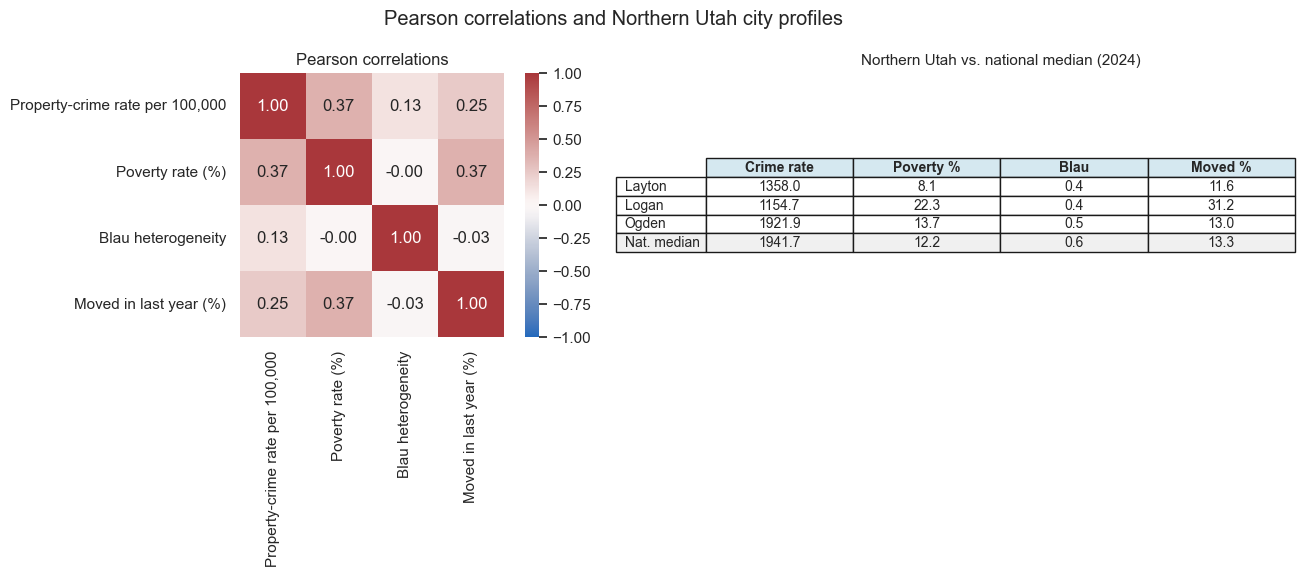

wrote C:\Users\Owner\OneDrive\Capstone\scripts\figures\02_correlation_heatmap.png


In [8]:
corr = df[H0_COLS].corr(method="pearson")
print(corr.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5),
                         gridspec_kw={"width_ratios": [4, 5]})

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    cmap="vlag",
    square=True,
    xticklabels=[LABELS[c] for c in H0_COLS],
    yticklabels=[LABELS[c] for c in H0_COLS],
    ax=axes[0],
)
axes[0].set_title("Pearson correlations")

SHORT = {
    "property_crime_rate": "Crime rate",
    "poverty_rate": "Poverty %",
    "blau_heterogeneity": "Blau",
    "pct_moved_year": "Moved %",
}
nu24 = nu[nu["year"] == 2024].set_index("city")[H0_COLS]
nat_med = df[df["year"] == 2024][H0_COLS].median()
tbl_data = pd.concat([nu24, nat_med.to_frame("Nat. median").T])
tbl_data = tbl_data.rename(columns=SHORT).round(1)
axes[1].axis("off")
tbl = axes[1].table(
    cellText=tbl_data.values,
    rowLabels=tbl_data.index,
    colLabels=tbl_data.columns,
    loc="center",
    cellLoc="center",
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 1.8)
for (r, c), cell in tbl.get_celld().items():
    if r == 0:
        cell.set_text_props(fontweight="bold")
        cell.set_facecolor("#D5E8F0")
    elif tbl_data.index[r - 1] == "Nat. median":
        cell.set_facecolor("#F0F0F0")
axes[1].set_title("Northern Utah vs. national median (2024)", fontsize=11)

fig.suptitle("Pearson correlations and Northern Utah city profiles")
fig.tight_layout()
corr_path = FIGDIR / "02_correlation_heatmap.png"
fig.savefig(corr_path, dpi=150)
plt.show()
print("wrote", corr_path)


The Pearson matrix describes pairwise linear association (Pearson, 1896). The rate’s strongest linear association among the three locked predictors is with poverty (0.37), then residential mobility (0.25), then Blau heterogeneity (0.13). Those magnitudes are moderate.

Among the predictors, poverty and percent moved correlate at 0.37. Blau heterogeneity is nearly uncorrelated with poverty (−0.004) and with mobility (−0.03). The three mediators are largely independent of one another.

The companion table shows each Northern Utah city’s 2024 predictor values against the national median. Logan’s poverty (22.3%) and mobility (31.2%) are roughly double the national medians, while Layton sits below the median on every measure.

## Arson Coverage

The Uniform Crime Reporting program classifies arson as a property offense and still withholds it from estimated volume totals because participation and collection procedures vary across agencies (Federal Bureau of Investigation, 2019). Notebook 01 therefore kept arson as a companion column and did not add it to the count.

A recorded zero is a count; a null value is incomplete coverage. If any place-year has a null arson value, arson stays out of the target.

In [9]:
arson_null = int(df["arson"].isna().sum())
arson_zero = int((df["arson"] == 0).sum())
arson_pos = int((df["arson"] > 0).sum())
print("place-years", len(df))
print("arson null values", arson_null, f"({arson_null / len(df):.1%})")
print("arson zero", arson_zero)
print("arson positive", arson_pos)
print("arson usable as a fourth count in the target?", arson_null == 0)
if arson_null > 0:
    print("Decision: arson remains out of the property-crime count.")


place-years 2182
arson null values 87 (4.0%)
arson zero 115
arson positive 1980
arson usable as a fourth count in the target? False
Decision: arson remains out of the property-crime count.


Eighty-seven place-years (4.0%) have a null arson value. Because coverage is incomplete, arson remains out of the property-crime count.

## Close

The cleaned table is now described. The property-crime rate and the three locked predictors have univariate summaries, histograms, scatter plots, and a Pearson matrix. All three Northern Utah briefing cities — Ogden, Layton, and Logan — are called out on the bivariate scatter plots, showing that Logan’s high-poverty, high-mobility profile stands apart from Layton’s calm corner and Ogden’s middle-of-the-cloud position. Arson stays out of the target.

## References

Blau, P. M. (1977). *Inequality and heterogeneity: A primitive theory of social structure*. Free Press.

Federal Bureau of Investigation. (2019). *Property crime*. Uniform Crime Reporting Program. https://ucr.fbi.gov/crime-in-the-u.s/2019/crime-in-the-u.s.-2019/topic-pages/property-crime

Messner, S. F. (1986). Modernization, structural characteristics, and societal rates of crime: An application of Blau's macrosociological theory. *The Sociological Quarterly, 27*(1), 27–41. https://doi.org/10.1111/j.1533-8525.1986.tb00247.x

Pearson, K. (1896). Mathematical contributions to the theory of evolution. III. Regression, heredity, and panmixia. *Philosophical Transactions of the Royal Society of London. Series A, 187*, 253–318. https://doi.org/10.1098/rsta.1896.0007

Tukey, J. W. (1977). *Exploratory data analysis*. Addison-Wesley.
